Code Cell 1: Setup & Data Acquisition Loop

In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss


In [2]:
# Set seed for reproducibility
np.random.seed(42)


Put your API key below

In [ ]:
CFBD_API_KEY = ""
headers = {"Authorization": f"Bearer {CFBD_API_KEY}"}

In [4]:
seasons = range(2020, 2026)
weeks = range(1, 16)
raw_stats_list = []

# Data ingestion loop
for yr in seasons:
    for wk in weeks:
        url = f"https://api.collegefootballdata.com/games/teams?year={yr}&week={wk}&seasonType=regular&division=fbs"
        try:
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                data = response.json()
                for game in data:
                    game_id = game.get("id")
                    teams = game.get("teams", [])
                    if len(teams) == 2:
                        for idx, team_data in enumerate(teams):
                            opp_data = teams[1 - idx]
                            
                            # Helper to extract metric by name
                            def get_stat(t_data, stat_name):
                                for s in t_data.get("stats", []):
                                    if s.get("category") == stat_name:
                                        return s.get("stat")
                                return None

                            row = {
                                "game_id": game_id,
                                "season": str(yr),
                                "week_num": wk,
                                "team": team_data.get("school"),
                                "opponent": opp_data.get("school"),
                                "home_away": "home" if team_data.get("homeAway") == "home" else "away",
                                "points": team_data.get("points"),
                                "points_allowed": opp_data.get("points"),
                                "total_yards": get_stat(team_data, "totalYards"),
                                "total_yards_allowed": get_stat(opp_data, "totalYards"),
                                "net_passing_yards": get_stat(team_data, "netPassingYards"),
                                "net_passing_yards_allowed": get_stat(opp_data, "netPassingYards"),
                                "rushing_yards": get_stat(team_data, "rushingYards"),
                                "rushing_yards_allowed": get_stat(opp_data, "rushingYards"),
                                "turnovers": get_stat(team_data, "turnovers"),
                                "turnovers_allowed": get_stat(opp_data, "turnovers"),
                                "first_downs": get_stat(team_data, "firstDowns"),
                                "first_downs_allowed": get_stat(opp_data, "firstDowns"),
                                "third_down_eff": get_stat(team_data, "thirdDownEff"),
                                "third_down_eff_allowed": get_stat(opp_data, "thirdDownEff"),
                                "total_penalties_yards": get_stat(team_data, "totalPenaltiesYards"),
                                "total_penalties_yards_allowed": get_stat(opp_data, "totalPenaltiesYards"),
                                "possession_time": get_stat(team_data, "possessionTime"),
                                "possession_time_allowed": get_stat(opp_data, "possessionTime"),
                            }
                            raw_stats_list.append(row)
        except Exception as e:
            continue

raw_team_stats = pd.DataFrame(raw_stats_list)


In [5]:
print(f"Total Rows Loaded: {len(raw_team_stats)}")
raw_team_stats.head()

Total Rows Loaded: 15248


,game_id,season,week_num,team,opponent,home_away,points,points_allowed,total_yards,total_yards_allowed,...,turnovers,turnovers_allowed,first_downs,first_downs_allowed,third_down_eff,third_down_eff_allowed,total_penalties_yards,total_penalties_yards_allowed,possession_time,possession_time_allowed
0,401239884,2020,1,None,None,away,14,24,230,364,...,2,2,14,19,3-8,8-13,5-45,4-40,23:13,36:47
1,401239884,2020,1,None,None,home,24,14,364,230,...,2,2,19,14,8-13,3-8,4-40,5-45,36:47,23:13
2,401234576,2020,1,None,None,home,3,55,149,580,...,1,1,7,28,2-12,6-11,6-54,1-5,22:40,37:20
3,401234576,2020,1,None,None,away,55,3,580,149,...,1,1,28,7,6-11,2-12,1-5,6-54,37:20,22:40
4,401235700,2020,1,None,None,home,42,0,368,184,...,0,4,24,13,13-15,3-9,7-74,5-53,35:29,24:31


Model 1: Game-Level Differentials
Code Cell 2: Feature Engineering (Differentials)

In [6]:
def parse_time_sec(time_str):
    if pd.isna(time_str):
        return 1800.0
    parts = str(time_str).split(":")
    if len(parts) == 2:
        return float(parts[0]) * 60 + float(parts[1])
    return 1800.0

def parse_split_eff(eff_str, pos=0):
    if pd.isna(eff_str):
        return 0.0
    parts = str(eff_str).split("-")
    if len(parts) == 2:
        try:
            return float(parts[pos])
        except ValueError:
            return 0.0
    return 0.0



In [7]:
df = raw_team_stats.copy()
df = df.dropna(subset=["points", "points_allowed"])
df = df[df["points"] != df["points_allowed"]]

df["points"] = df["points"].astype(float)
df["points_allowed"] = df["points_allowed"].astype(float)
df["win"] = (df["points"] > df["points_allowed"]).astype(int)

# Parsing nested string fields
df["td_comp"] = df["third_down_eff"].apply(lambda x: parse_split_eff(x, 0))
df["td_att"] = df["third_down_eff"].apply(lambda x: parse_split_eff(x, 1))
df["td_comp_opp"] = df["third_down_eff_allowed"].apply(lambda x: parse_split_eff(x, 0))
df["td_att_opp"] = df["third_down_eff_allowed"].apply(lambda x: parse_split_eff(x, 1))

df["pen_yds"] = df["total_penalties_yards"].apply(lambda x: parse_split_eff(x, 1))
df["pen_yds_opp"] = df["total_penalties_yards_allowed"].apply(lambda x: parse_split_eff(x, 1))

df["top_sec"] = df["possession_time"].apply(parse_time_sec)
df["top_sec_opp"] = df["possession_time_allowed"].apply(parse_time_sec)

df["third_down_pct"] = np.where(df["td_att"] > 0, df["td_comp"] / df["td_att"], 0.0)
df["third_down_pct_opp"] = np.where(df["td_att_opp"] > 0, df["td_comp_opp"] / df["td_att_opp"], 0.0)

num_cols = ["turnovers", "turnovers_allowed", "net_passing_yards", "net_passing_yards_allowed",
            "rushing_yards", "rushing_yards_allowed", "first_downs", "first_downs_allowed"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

In [8]:
# Computing differentials
df["turnover_margin"] = df["turnovers_allowed"] - df["turnovers"]
df["pass_yards_diff"] = df["net_passing_yards"] - df["net_passing_yards_allowed"]
df["rush_yards_diff"] = df["rushing_yards"] - df["rushing_yards_allowed"]
df["first_downs_diff"] = df["first_downs"] - df["first_downs_allowed"]
df["third_down_pct_diff"] = df["third_down_pct"] - df["third_down_pct_opp"]
df["penalty_yards_diff"] = df["pen_yds"] - df["pen_yds_opp"]
df["top_seconds_diff"] = df["top_sec"] - df["top_sec_opp"]
df["is_home"] = (df["home_away"].str.lower() == "home").astype(int)

# Filter every 2nd row to prevent double-counting full game perspectives
cfb_diff = df.iloc[1::2].reset_index(drop=True)

diff_predictors = [
    "is_home", "turnover_margin", "pass_yards_diff", "rush_yards_diff",
    "first_downs_diff", "third_down_pct_diff", "penalty_yards_diff", "top_seconds_diff"
]

cfb_diff = cfb_diff.dropna(subset=["win"] + diff_predictors)
cfb_diff.head()

,game_id,season,week_num,team,opponent,home_away,points,points_allowed,total_yards,total_yards_allowed,...,third_down_pct,third_down_pct_opp,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home
0,401239884,2020,1,None,None,home,24.0,14.0,364,230,...,0.615385,0.375000,0.0,79.0,55.0,5.0,0.240385,-5.0,814.0,1
1,401234576,2020,1,None,None,away,55.0,3.0,580,149,...,0.545455,0.166667,0.0,249.0,182.0,21.0,0.378788,-49.0,880.0,0
2,401235700,2020,1,None,None,away,0.0,42.0,184,368,...,0.333333,0.866667,-4.0,81.0,-265.0,-11.0,-0.533333,-21.0,-658.0,0
3,401207098,2020,1,None,None,home,57.0,31.0,721,569,...,0.647059,0.444444,-1.0,-119.0,271.0,5.0,0.202614,-30.0,-538.0,1
4,401238035,2020,1,None,None,home,45.0,35.0,459,293,...,0.000000,0.000000,0.0,33.0,133.0,0.0,0.000000,0.0,0.0,1


Cell 3: Stratified Train/Test Split & Logistic Regression (Differentials)

In [9]:
X_diff = cfb_diff[diff_predictors]
y_diff = cfb_diff["win"]
strata_diff = cfb_diff["season"]

X_train, X_test, y_train, y_test = train_test_split(
    X_diff, y_diff, test_size=0.20, random_state=2026, stratify=strata_diff
)

test_indices = X_test.index
test_seasons = cfb_diff.loc[test_indices, "season"]

# Standardizing features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=diff_predictors, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=diff_predictors, index=X_test.index)

# Add constant for statsmodels Logit
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)


In [10]:
# Fit Logistic Regression Model
logit_model_diff = sm.Logit(y_train, X_train_sm).fit(disp=False)

# Feature Importance Summary Table
summary_df = pd.DataFrame({
    "Predictor": logit_model_diff.params.index,
    "Std Beta": logit_model_diff.params.values,
    "Odds Ratio (1 SD)": np.exp(logit_model_diff.params.values),
    "z-statistic": logit_model_diff.tvalues.values,
    "p-value": logit_model_diff.pvalues.values
})
summary_df = summary_df[summary_df["Predictor"] != "const"].copy()
summary_df["Importance (|z|)"] = summary_df["z-statistic"].abs()
summary_df = summary_df.sort_values(by="Importance (|z|)", ascending=False)

print(summary_df.to_string(index=False))

          Predictor  Std Beta  Odds Ratio (1 SD)  z-statistic       p-value  Importance (|z|)
    turnover_margin  1.627080           5.088994    27.349656 1.090118e-164         27.349656
    rush_yards_diff  2.642082          14.042414    25.934389 2.727800e-148         25.934389
    pass_yards_diff  1.621015           5.058222    18.335029  4.347842e-75         18.335029
third_down_pct_diff  0.927694           2.528672    14.271307  3.303282e-46         14.271307
 penalty_yards_diff -0.321821           0.724828    -6.739543  1.588854e-11          6.739543
   top_seconds_diff -0.378184           0.685105    -6.165971  7.005195e-10          6.165971
            is_home  0.226213           1.253842     5.290109  1.222433e-07          5.290109
   first_downs_diff -0.442961           0.642132    -4.106399  4.018757e-05          4.106399


C:\Users\mschuck1\AppData\Local\Temp\1\ipykernel_7540\246387249.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Importance (|z|)", y="Predictor", palette="mako")


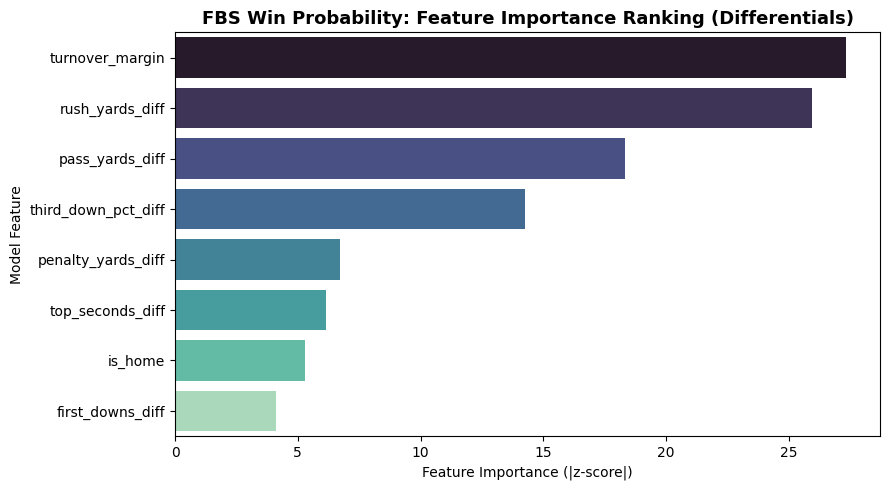

In [11]:
# Plot Feature Importance
plt.figure(figsize=(9, 5))
sns.barplot(data=summary_df, x="Importance (|z|)", y="Predictor", palette="mako")
plt.title("FBS Win Probability: Feature Importance Ranking (Differentials)", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance (|z-score|)")
plt.ylabel("Model Feature")
plt.tight_layout()
plt.show()

Out-of-Sample Performance & Calibration Plots (Differentials)

In [12]:
pred_probs_diff = logit_model_diff.predict(X_test_sm)
pred_class_diff = (pred_probs_diff >= 0.5).astype(int)

metrics_diff = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "Log Loss", "Brier Score"],
    "Test Score": [
        accuracy_score(y_test, pred_class_diff),
        roc_auc_score(y_test, pred_probs_diff),
        log_loss(y_test, pred_probs_diff),
        brier_score_loss(y_test, pred_probs_diff)
    ]
})

print("Out-of-Sample Performance (Differentials Model):")
print(metrics_diff.to_string(index=False))

Out-of-Sample Performance (Differentials Model):
     Metric  Test Score
   Accuracy    0.895082
    ROC AUC    0.965619
   Log Loss    0.240952
Brier Score    0.074562


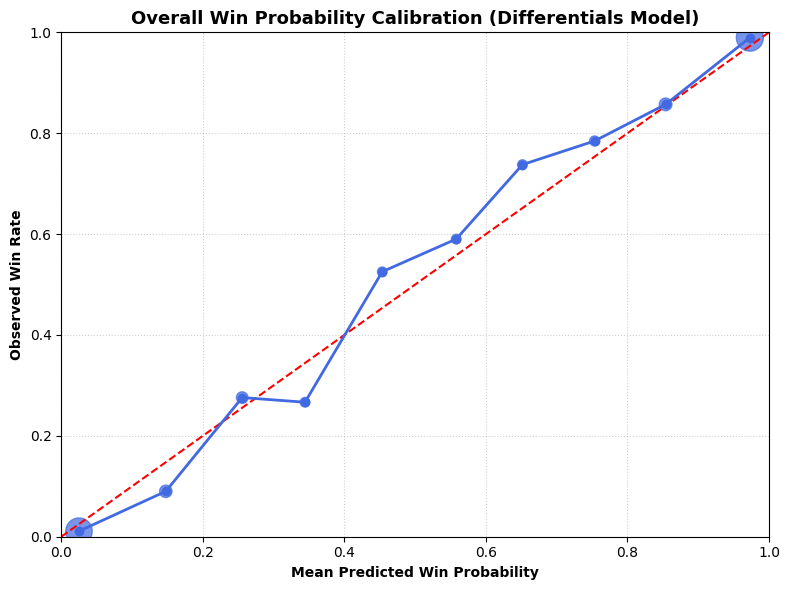

In [13]:
# Function for aggregate calibration plot
def plot_overall_calibration(y_true, y_probs, title_suffix=""):
    df_cal = pd.DataFrame({"actual": y_true, "pred": y_probs})
    df_cal["prob_bin"] = pd.cut(df_cal["pred"], bins=np.linspace(0, 1, 11), include_lowest=True)
    
    agg = df_cal.groupby("prob_bin", observed=False).agg(
        mean_pred=("pred", "mean"),
        actual_win_rate=("actual", "mean"),
        game_count=("actual", "count")
    ).reset_index().dropna()

    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect Calibration")
    plt.plot(agg["mean_pred"], agg["actual_win_rate"], "o-", color="royalblue", linewidth=2)
    plt.scatter(agg["mean_pred"], agg["actual_win_rate"], s=agg["game_count"] * 0.8, color="royalblue", alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Mean Predicted Win Probability", fontweight="bold")
    plt.ylabel("Observed Win Rate", fontweight="bold")
    plt.title(f"Overall Win Probability Calibration {title_suffix}", fontsize=13, fontweight="bold")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_overall_calibration(y_test, pred_probs_diff, "(Differentials Model)")

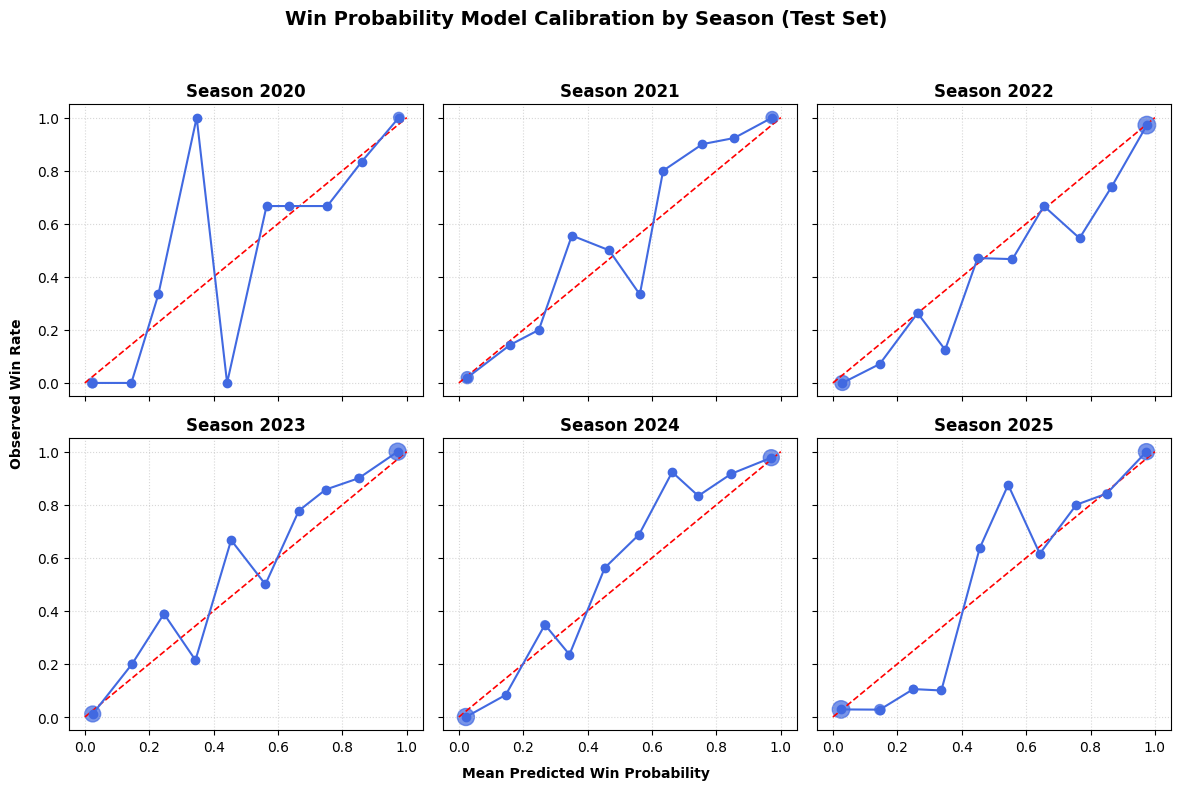

In [14]:
# Function for faceted season calibration plots
def plot_season_calibration(y_true, y_probs, seasons_series):
    df_cal = pd.DataFrame({"actual": y_true, "pred": y_probs, "season": seasons_series.values})
    df_cal["prob_bin"] = pd.cut(df_cal["pred"], bins=np.linspace(0, 1, 11), include_lowest=True)
    
    agg = df_cal.groupby(["season", "prob_bin"], observed=False).agg(
        mean_pred=("pred", "mean"),
        actual_win_rate=("actual", "mean"),
        game_count=("actual", "count")
    ).reset_index().dropna()

    unique_seasons = sorted(agg["season"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for idx, s in enumerate(unique_seasons):
        ax = axes[idx]
        sub = agg[agg["season"] == s]
        ax.plot([0, 1], [0, 1], "r--", linewidth=1.2)
        ax.plot(sub["mean_pred"], sub["actual_win_rate"], "o-", color="royalblue", linewidth=1.5)
        ax.scatter(sub["mean_pred"], sub["actual_win_rate"], s=sub["game_count"] * 1.5, color="royalblue", alpha=0.7)
        ax.set_title(f"Season {s}", fontweight="bold")
        ax.grid(True, linestyle=":", alpha=0.5)

    plt.suptitle("Win Probability Model Calibration by Season (Test Set)", fontsize=14, fontweight="bold")
    fig.text(0.5, 0.02, "Mean Predicted Win Probability", ha="center", fontweight="bold")
    fig.text(0.02, 0.5, "Observed Win Rate", va="center", rotation="vertical", fontweight="bold")
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
    plt.show()

plot_season_calibration(y_test, pred_probs_diff, test_seasons)

Individual Team Features (No Differentials)

In [15]:
ind_predictors = [
    "is_home", "turnovers", "turnovers_allowed",
    "rushing_yards", "rushing_yards_allowed",
    "net_passing_yards", "net_passing_yards_allowed",
    "first_downs", "first_downs_allowed",
    "third_down_pct", "third_down_pct_opp",
    "pen_yds", "top_sec"
]

cfb_ind = df.iloc[1::2].reset_index(drop=True)
cfb_ind = cfb_ind.dropna(subset=["win"] + ind_predictors)

X_ind = cfb_ind[ind_predictors]
y_ind = cfb_ind["win"]
strata_ind = cfb_ind["season"]

X_train_ind, X_test_ind, y_train_ind, y_test_ind = train_test_split(
    X_ind, y_ind, test_size=0.20, random_state=2026, stratify=strata_ind
)

test_indices_ind = X_test_ind.index
test_seasons_ind = cfb_ind.loc[test_indices_ind, "season"]


In [16]:
# Normalize features
scaler_ind = StandardScaler()
X_train_ind_scaled = pd.DataFrame(scaler_ind.fit_transform(X_train_ind), columns=ind_predictors, index=X_train_ind.index)
X_test_ind_scaled = pd.DataFrame(scaler_ind.transform(X_test_ind), columns=ind_predictors, index=X_test_ind.index)

X_train_ind_sm = sm.add_constant(X_train_ind_scaled)
X_test_ind_sm = sm.add_constant(X_test_ind_scaled)

logit_model_ind = sm.Logit(y_train_ind, X_train_ind_sm).fit(disp=False)

In [17]:
# Feature Importance
summary_ind_df = pd.DataFrame({
    "Predictor": logit_model_ind.params.index,
    "Std Beta": logit_model_ind.params.values,
    "Odds Ratio (1 SD)": np.exp(logit_model_ind.params.values),
    "z-statistic": logit_model_ind.tvalues.values,
    "p-value": logit_model_ind.pvalues.values
})
summary_ind_df = summary_ind_df[summary_ind_df["Predictor"] != "const"].copy()
summary_ind_df["Importance (|z|)"] = summary_ind_df["z-statistic"].abs()
summary_ind_df = summary_ind_df.sort_values(by="Importance (|z|)", ascending=False)

print(summary_ind_df.to_string(index=False))

                Predictor  Std Beta  Odds Ratio (1 SD)  z-statistic       p-value  Importance (|z|)
        turnovers_allowed  1.130622           3.097582    21.993748 3.305278e-107         21.993748
                turnovers -1.082083           0.338889   -21.206241 8.363632e-100         21.206241
            rushing_yards  1.609257           4.999094    20.664872  7.174678e-95         20.664872
    rushing_yards_allowed -1.511846           0.220503   -19.546095  4.453363e-85         19.546095
        net_passing_yards  1.170925           3.224975    15.110291  1.385273e-51         15.110291
net_passing_yards_allowed -1.074055           0.341620   -13.687375  1.207948e-42         13.687375
       third_down_pct_opp -0.640906           0.526815   -11.137428  8.246707e-29         11.137428
           third_down_pct  0.599806           1.821765    10.727043  7.598931e-27         10.727043
                  top_sec -0.335976           0.714640    -5.693353  1.245682e-08          5.693353


C:\Users\mschuck1\AppData\Local\Temp\1\ipykernel_7540\4288641110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_ind_df, x="Importance (|z|)", y="Predictor", palette="mako")


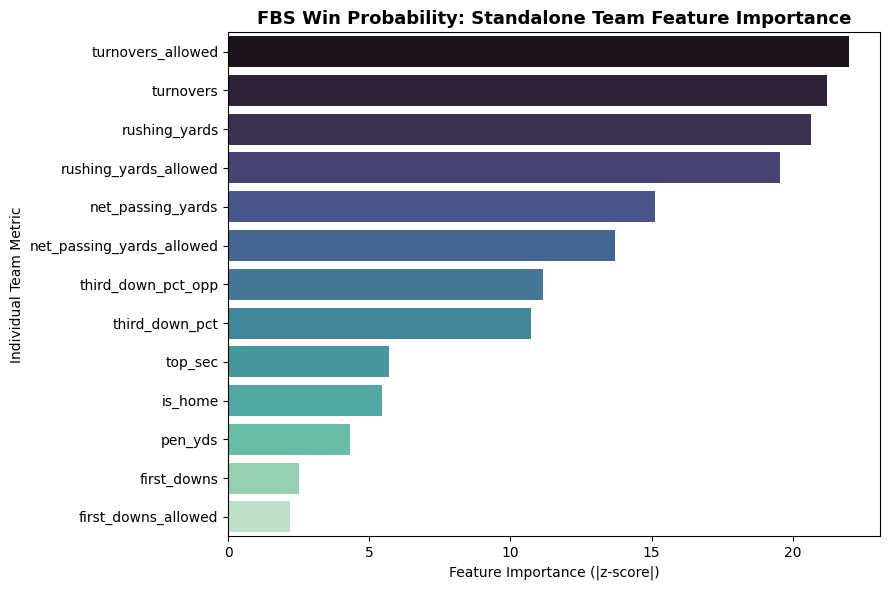

In [18]:
# Visualization
plt.figure(figsize=(9, 6))
sns.barplot(data=summary_ind_df, x="Importance (|z|)", y="Predictor", palette="mako")
plt.title("FBS Win Probability: Standalone Team Feature Importance", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance (|z-score|)")
plt.ylabel("Individual Team Metric")
plt.tight_layout()
plt.show()

 Out-of-Sample Evaluation & Calibration Plots (Individual Model)

In [19]:
pred_probs_ind = logit_model_ind.predict(X_test_ind_sm)
pred_class_ind = (pred_probs_ind >= 0.5).astype(int)

metrics_ind = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "Log Loss", "Brier Score"],
    "Test Score": [
        accuracy_score(y_test_ind, pred_class_ind),
        roc_auc_score(y_test_ind, pred_probs_ind),
        log_loss(y_test_ind, pred_probs_ind),
        brier_score_loss(y_test_ind, pred_probs_ind)
    ]
})

print("Out-of-Sample Performance (Individual Team Feature Model):")
print(metrics_ind.to_string(index=False))


Out-of-Sample Performance (Individual Team Feature Model):
     Metric  Test Score
   Accuracy    0.899016
    ROC AUC    0.964377
   Log Loss    0.245076
Brier Score    0.076024


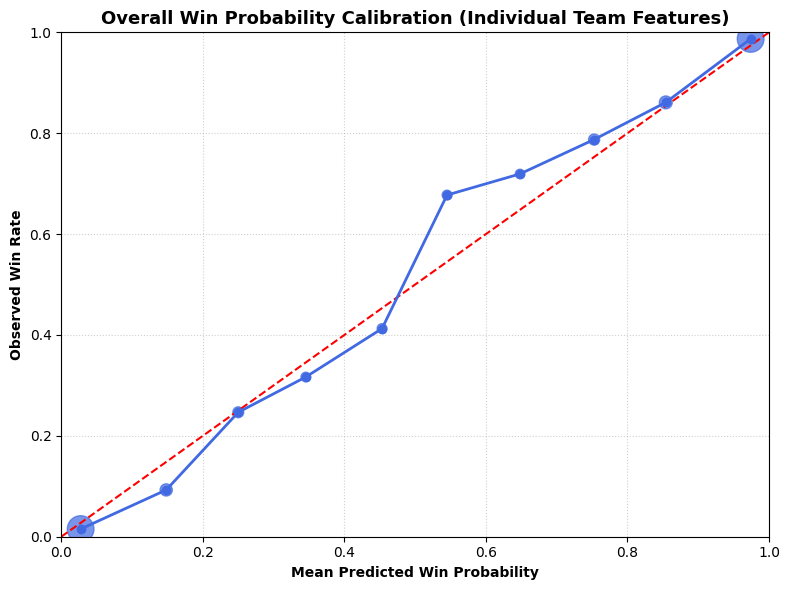

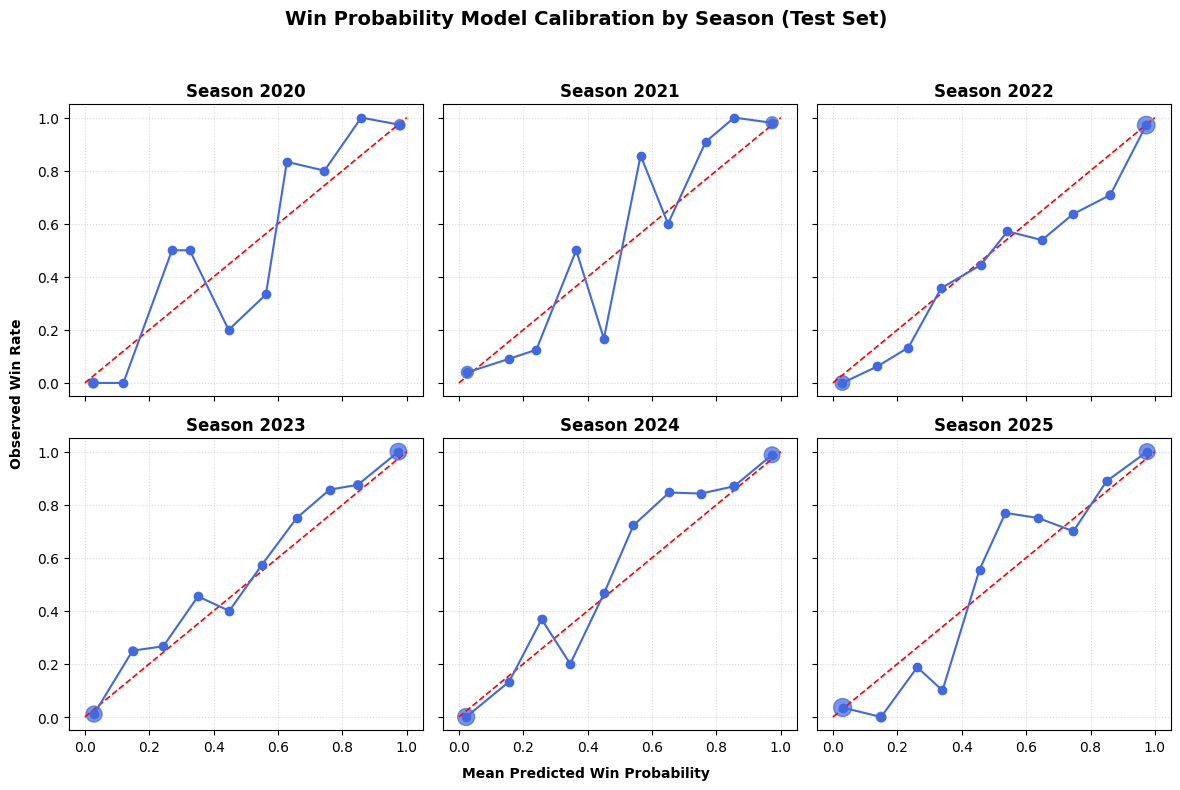

In [20]:


# Overall Calibration Plot
plot_overall_calibration(y_test_ind, pred_probs_ind, "(Individual Team Features)")

# Season Calibration Plots
plot_season_calibration(y_test_ind, pred_probs_ind, test_seasons_ind)